# Exercise 3

In [75]:
import math
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

## Part 1

### 1)

In [76]:
def exponential(lam,n):
    U = np.random.uniform(0,1,n)
    return -np.log(U) / lam


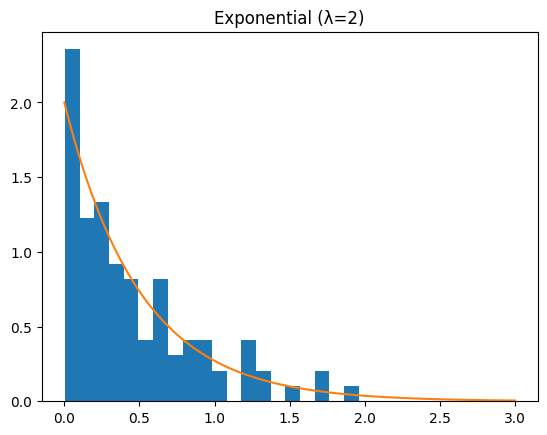

D: 0.6597355609013527
p: 3.013404336709913e-43


In [87]:
n = 100
lam = 2

sample_exponential = exponential(lam,n)

x = np.linspace(0,6/lam,n)

theory_exponential = lam * np.exp(-lam * x)

plt.hist(sample_exponential,bins=int(n/5), density=True)
plt.plot(x,theory_exponential)
plt.title(f"Exponential (λ={lam})")
plt.show()

D, p = stats.kstest(
    sample_exponential,
    lambda x: stats.expon.cdf(x,1/lam)
)
print(f"D:",D)
print(f"p:",p)

### 2)

In [92]:
def normal(mean,std,n):
    U1 = np.random.uniform(0,1,int(n/2))
    U2 = np.random.uniform(0,1,int(n/2))

    Z1 = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)
    Z2 = np.sqrt(-2 * np.log(U1)) * np.sin(2 * np.pi * U2)
    
    Z = np.concatenate([Z1,Z2])

    return mean + std * Z

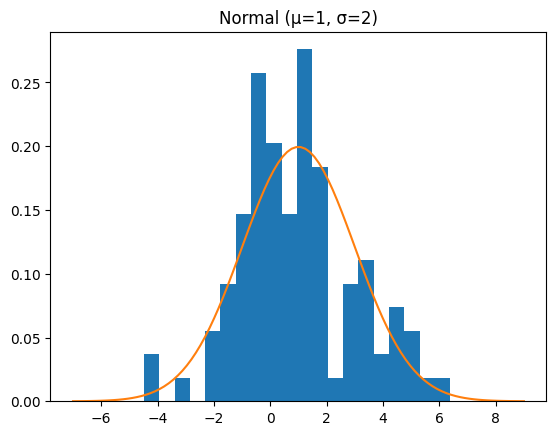

D: 0.0888473977765295
p: 0.38621886948041406


In [93]:
n = 100
mean = 1
std = 2

sample_normal = normal(mean,std,n)

x = np.linspace(mean-4*std,mean+4*std,n)

theory_normal = 1/(np.sqrt(2*np.pi*std**2)) * np.exp(-(x-mean)**2/(2*std**2))

plt.hist(sample_normal,bins=int(n/5), density=True)
plt.plot(x,theory_normal)
plt.title(f"Normal (μ={mean}, σ={std})")
plt.show()

D, p = stats.kstest(
    sample_normal,
    lambda x: stats.norm.cdf(x,mean,std)
)
print(f"D:",D)
print(f"p:",p)

### 3)

In [88]:
def pareto(k,beta,n):
    U = np.random.uniform(0,1,n)
    return beta * (U**(-1/k))

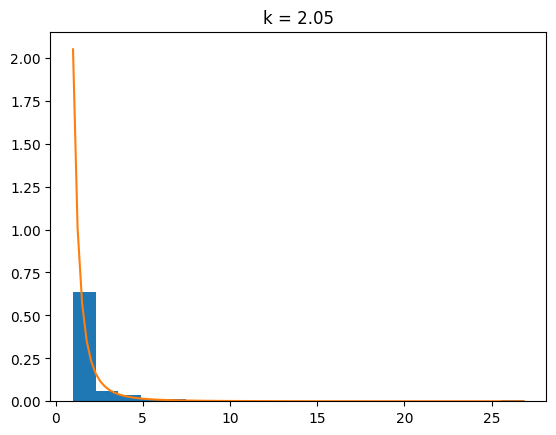

D_2.05: 0.06512848051294409
p_2.05: 0.7651331657886041


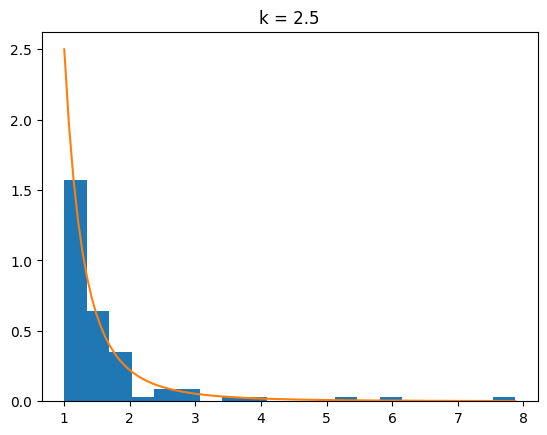

D_2.5: 0.09000283970281853
p_2.5: 0.3705941211214878


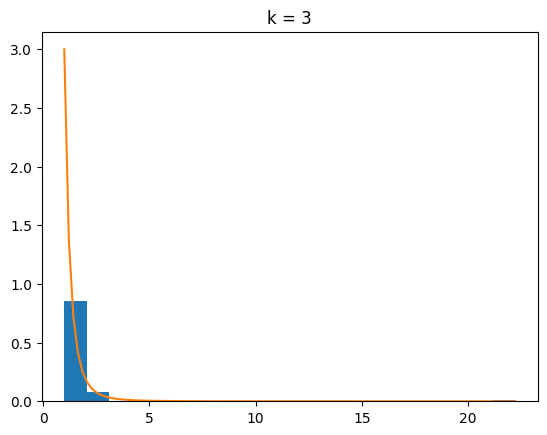

D_3: 0.05636142232784369
p_3: 0.8905719353208182


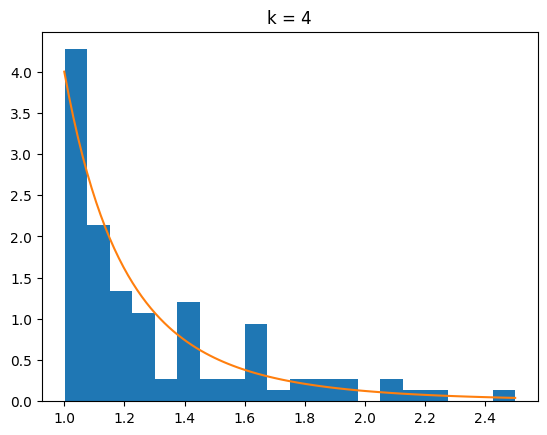

D_4: 0.08653048310545547
p_4: 0.4187452649212442


In [ ]:
n = 100

K = [2.05,2.5,3,4]
beta = 1

samples_pareto = [pareto(k,beta,n) for k in K]

X = [np.linspace(beta,np.max(sample),n) for sample in samples_pareto]

theory_pareto = [k * beta**k / x**(k + 1) for k,x in zip(K,X)]


for i in range(len(K)):
    sample_pareto = samples_pareto[i]

    plt.hist(samples_pareto[i],bins=int(n/5), density=True)
    plt.plot(X[i],theory_pareto[i])
    plt.title(f"k = {K[i]}")
    plt.show()

    D, p = stats.kstest(
        sample_pareto,
        lambda x: stats.pareto.cdf(x,K[i],beta)
    )
    print(f"D_{K[i]}:",D)
    print(f"p_{K[i]}:",p)


## Part 2

In [89]:
def pareto_support(k,beta,n):
    U = np.random.uniform(0,1,n)
    return beta * (U**(-1/k) - 1)

In [91]:
n = 100

k = 2.5
beta = 1

sample_paretoS = pareto_support(k,beta,n)

sample_mean = np.mean(sample_paretoS)
sample_var = np.var(sample_paretoS)

theory_mean = beta * (k / (k - 1))
theory_var = beta**2 * (k / ((k - 1)**2 * (k - 2)))

print(f"k = {k}")

print("Sample mean:", sample_mean)
print("Theoretical mean", theory_mean)

print("Sample variance", sample_var)
print("Theoretical variance", theory_var)

k = 2.5
Sample mean: 0.607688747016288
Theoretical mean 1.6666666666666667
Sample variance 0.9854134640396767
Theoretical variance 2.2222222222222223


## Part 3

In [100]:
n = 10
c = 100

mean = 1
std = 2

for _ in range(c):
    sample = normal(mean,std,n)

    CI_mean = stats.t.interval(confidence = 0.95, df=n-1, loc=np.mean(sample), scale=np.std(sample, ddof=1)/np.sqrt(n))

    var = np.var(sample, ddof=1)

    alpha = 0.05

    chi2_lower = stats.chi2.ppf(alpha/2, df=n-1)
    chi2_upper = stats.chi2.ppf(1 - alpha/2, df=n-1)

    CI_var = ((n-1)*var/chi2_upper,(n-1)*var/chi2_lower)

    print("CI of mean:", CI_mean)
    print("CI of variance:", CI_var)


CI of mean: (np.float64(1.2346520930434104), np.float64(2.8314526750950555))
CI of variance: (np.float64(0.5893382478998831), np.float64(4.15156578143239))
CI of mean: (np.float64(-0.9865814075484928), np.float64(2.9542392813275065))
CI of variance: (np.float64(3.5895219393727804), np.float64(25.286219769894256))
CI of mean: (np.float64(-0.047515178679433445), np.float64(2.3330779401028092))
CI of variance: (np.float64(1.3098863332709851), np.float64(9.227433139037647))
CI of mean: (np.float64(-1.0751620540935187), np.float64(2.88075224294094))
CI of variance: (np.float64(3.6170708162234564), np.float64(25.480286547093467))
CI of mean: (np.float64(-0.3112617908050813), np.float64(1.9691479552791642))
CI of variance: (np.float64(1.2019573014549365), np.float64(8.467132111728871))
CI of mean: (np.float64(0.19423662188240676), np.float64(3.579947916772671))
CI of variance: (np.float64(2.6494950216609605), np.float64(18.66424402149395))
CI of mean: (np.float64(-0.986628699652396), np.float

## Part 4

In [102]:
def pareto_comp(k,beta,n):
    y = np.random.exponential(1/k,n)
    return beta * np.exp(y)

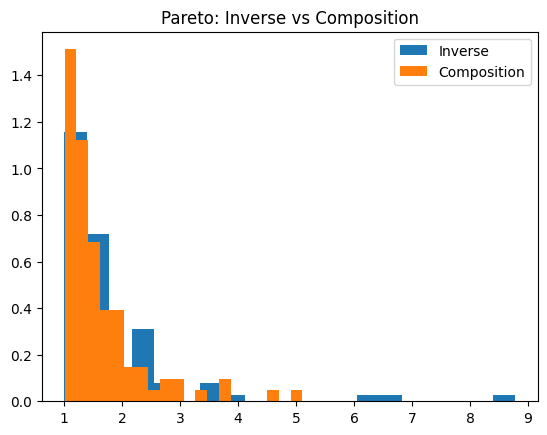

In [108]:
n = 100

k = 2.5
beta = 1

inv = pareto(k,beta,n)
comp = pareto_comp(k,beta,n)

plt.hist(inv, bins=int(n/5), density=True, label="Inverse")
plt.hist(comp, bins=int(n/5), density=True, label="Composition")

plt.legend()
plt.title("Pareto: Inverse vs Composition")
plt.show()